# Generation perplexity during training

List any number of run names below, then run all cells in Colab or a local Jupyter
notebook (CPU is sufficient). In Colab, Drive is mounted automatically. Locally,
set `BASE_DIR` to the folder containing your run directories, either downloaded
or synced with Google Drive for desktop. Each run uses `generation_metrics.jsonl` and `metrics.jsonl`.
No models or datasets are loaded.

Local dependencies: `pip install pandas numpy matplotlib ipykernel` in your notebook
kernel environment. Locally, the notebook uses the configured synced Drive folder
when available, otherwise this repository's `outputs` directory.

On the left axis, dotted lines show **mean per-answer perplexity**, solid lines
show **median perplexity**, and shading shows **25th–75th percentiles (IQR)**. Dashed lines show **validation weighted loss**
from `metrics.jsonl` on the right axis, starting at step 250 by default.
Each run uses the same color on both axes. Only `split="validation"` records
(or the spelling `"alidation"`) are used for loss; training/test records are excluded.
Validation loss is already an aggregate, so it is plotted directly without an IQR.
The two metrics keep their own evaluation steps; no interpolation or alignment is required.
A second, aligned panel shows mean per-answer **Distinct-1/2/3**, computed
in this notebook from each record's final text using sliding lexical n-grams.
Higher Distinct-n means greater lexical diversity.

The perplexity IQR describes the spread of answers, not a confidence interval for the mean.
It is different from token-pooled perplexity, which cannot be recovered from
per-answer perplexities alone without their scored token counts.
Compare runs scored with the same reference model/tokenizer and generation protocol.

In [1]:
from pathlib import Path

try:
    from google.colab import drive
except ModuleNotFoundError:
    # Jupyter may start in the repository root or in its notebooks directory.
    project_dir = Path.cwd()
    if project_dir.name == "notebooks":
        project_dir = project_dir.parent
    synced_outputs = Path(
        "/Users/rkuiper/Library/CloudStorage/GoogleDrive-ruurd.kuiper@gmail.com/"
        "My Drive/lad-generic-results/outputs"
    )
    DEFAULT_BASE_DIR = synced_outputs if synced_outputs.is_dir() else project_dir / "outputs"
    print(f"Running locally. Run folders: {DEFAULT_BASE_DIR}")
else:
    drive.mount("/content/drive")
    DEFAULT_BASE_DIR = Path("/content/drive/MyDrive/lad-generic-results/outputs")


Running locally. Run folders: /Users/rkuiper/Library/CloudStorage/GoogleDrive-ruurd.kuiper@gmail.com/My Drive/lad-generic-results/outputs


In [2]:
# Edit this list: one directory name per run, with as many runs as you like.
RUN_NAMES = [
    # "llama-3.1-8b-mask-legacy-comparison",
    # "llama-3.1-8b-mask-frontier-2",
    # "llama-3.1-8b-mask-frontier-all-tokens",
    "llama-3.1-8b-mask-frontier-answer90-padding10",
    "llama-3.1-8b-mask-frontier-answer90-padding10-long_1",
    "llama-3.1-8b-mask-frontier-answer90-padding10-long",
    # "gemma-2-9b-mask-frontier-answer90-padding10",
]
BASE_DIR = DEFAULT_BASE_DIR
# Local override: the directory containing <run>/generation_metrics.jsonl.
# BASE_DIR = Path("~/Downloads/lad-generic-results/outputs").expanduser()
LOG_Y = False
MIN_VALIDATION_STEP = 250  # Include validation loss from this step onward.



In [3]:
import json
import re
import numpy as np
import pandas as pd
from IPython.display import display


def read_records(path):
    if not path.is_file():
        print(f"File not found (skipping): {path}")
        return pd.DataFrame()
    records, malformed = [], 0
    with path.open() as stream:
        for line in stream:
            if not line.strip():
                continue
            try:
                record = json.loads(line)
            except json.JSONDecodeError:
                malformed += 1  # A running job may not have finished its last line.
                continue
            if isinstance(record, dict):
                records.append(record)
            else:
                malformed += 1
    if malformed:
        print(f"{path}: skipped {malformed} malformed record(s).")
    frame = pd.DataFrame(records)
    if "step" not in frame:
        return pd.DataFrame()
    frame["step"] = pd.to_numeric(frame["step"], errors="coerce")
    return frame.loc[np.isfinite(frame["step"]) & (frame["step"] >= 0)].copy()


DISTINCT_COLUMNS = ["distinct_1", "distinct_2", "distinct_3"]
TOKEN_PATTERN = re.compile(r"\w+|[^\w\s]", flags=re.UNICODE)


def distinct_n(text, n):
    """Return unique sliding lexical n-grams / all sliding lexical n-grams."""
    if not isinstance(text, str) or not text.strip():
        return np.nan
    tokens = TOKEN_PATTERN.findall(text)
    if len(tokens) < n:
        return np.nan
    ngrams = [tuple(tokens[index:index + n]) for index in range(len(tokens) - n + 1)]
    return len(set(ngrams)) / len(ngrams)


perplexity_summaries = {}
distinct_summaries = {}
validation_losses = {}
for run_name in dict.fromkeys(RUN_NAMES):
    run_dir = BASE_DIR / run_name
    generation_frame = read_records(run_dir / "generation_metrics.jsonl")
    if "prompt_index" in generation_frame and generation_frame["prompt_index"].notna().all():
        generation_frame = generation_frame.drop_duplicates(["step", "prompt_index"], keep="last")
    if "generation_perplexity" in generation_frame:
        frame = generation_frame.copy()
        values = pd.to_numeric(frame["generation_perplexity"], errors="coerce")
        valid = np.isfinite(values) & (values > 0)
        if (~valid).any():
            print(f"{run_name}: excluded {int((~valid).sum())} invalid perplexity value(s).")
        frame = frame.loc[valid].copy()
        frame["generation_perplexity"] = values.loc[valid]
        if not frame.empty:
            perplexity_summaries[run_name] = frame.groupby("step", sort=True)["generation_perplexity"].agg(
                mean="mean", median="median", q25=lambda values: values.quantile(0.25),
                q75=lambda values: values.quantile(0.75), n="count",
            )

    if "final" in generation_frame:
        frame = generation_frame[["step", "final"]].copy()
        for n, column in enumerate(DISTINCT_COLUMNS, start=1):
            frame[column] = frame["final"].map(lambda text, n=n: distinct_n(text, n))
        unavailable = frame[DISTINCT_COLUMNS].isna().sum()
        if unavailable.any():
            details = ", ".join(
                f"Distinct-{n}: {int(unavailable[column])}"
                for n, column in enumerate(DISTINCT_COLUMNS, start=1) if unavailable[column]
            )
            print(f"{run_name}: unavailable for empty/short answers — {details}.")
        summary = frame.groupby("step", sort=True)[DISTINCT_COLUMNS].mean().dropna(how="all")
        if not summary.empty:
            distinct_summaries[run_name] = summary

    # Load independently: loss can be available more often than generation metrics.
    frame = read_records(run_dir / "metrics.jsonl")
    if {"split", "weighted_loss"}.issubset(frame.columns):
        frame = frame.loc[frame["split"].isin(["validation", "alidation"])
                          & (frame["step"] >= MIN_VALIDATION_STEP)].copy()
        frame["weighted_loss"] = pd.to_numeric(frame["weighted_loss"], errors="coerce")
        # A resumed run may have logged the same validation step more than once.
        frame = frame.drop_duplicates("step", keep="last")
        valid = np.isfinite(frame["weighted_loss"]) & (frame["weighted_loss"] >= 0)
        if (~valid).any():
            print(f"{run_name}: excluded {int((~valid).sum())} invalid validation loss value(s).")
        frame = frame.loc[valid].sort_values("step")
        if not frame.empty:
            validation_losses[run_name] = frame.set_index("step")["weighted_loss"]
    print(f"{run_name}: {len(perplexity_summaries.get(run_name, []))} perplexity steps, "
          f"{len(distinct_summaries.get(run_name, []))} Distinct-n steps, "
          f"{len(validation_losses.get(run_name, []))} validation loss steps.")

if not perplexity_summaries and not distinct_summaries and not validation_losses:
    raise ValueError("No valid runs found. Check RUN_NAMES, BASE_DIR and MIN_VALIDATION_STEP.")

if perplexity_summaries:
    stats = pd.concat(perplexity_summaries, names=["run", "step"])
    display(stats)
if validation_losses:
    loss_stats = pd.concat(validation_losses, names=["run", "step"]).rename("weighted_loss").to_frame()
    display(loss_stats)
if distinct_summaries:
    distinct_stats = pd.concat(distinct_summaries, names=["run", "step"])
    display(distinct_stats)


/Users/rkuiper/Library/CloudStorage/GoogleDrive-ruurd.kuiper@gmail.com/My Drive/lad-generic-results/outputs/llama-3.1-8b-mask-frontier-answer90-padding10/metrics.jsonl: skipped 1 malformed record(s).
llama-3.1-8b-mask-frontier-answer90-padding10: 50 perplexity steps, 50 Distinct-n steps, 200 validation loss steps.
llama-3.1-8b-mask-frontier-answer90-padding10-long_1: 50 perplexity steps, 50 Distinct-n steps, 200 validation loss steps.
File not found (skipping): /Users/rkuiper/Library/CloudStorage/GoogleDrive-ruurd.kuiper@gmail.com/My Drive/lad-generic-results/outputs/llama-3.1-8b-mask-frontier-answer90-padding10-long/generation_metrics.jsonl
llama-3.1-8b-mask-frontier-answer90-padding10-long: 0 perplexity steps, 0 Distinct-n steps, 3 validation loss steps.


mean    median  \
run                                                step                         
llama-3.1-8b-mask-frontier-answer90-padding10      1000   10.077617  9.564633   
                                                   2000   10.050325  8.301641   
                                                   3000    8.962013  8.072796   
                                                   4000    8.767673  8.047727   
                                                   5000    9.208022  8.268168   
...                                                             ...       ...   
llama-3.1-8b-mask-frontier-answer90-padding10-l... 46000   7.307260  6.786951   
                                                   47000   7.525892  7.071033   
                                                   48000   7.465295  7.081060   
                                                   49000   7.062345  7.333994   
                                                   50000   7.731574  7.236226   

                                                               q25        q75  \
run                                                step                         
llama-3.1-8b-mask-frontier-answer90-padding10      1000   7.789172  11.334283   
                                                   2000   5.826568  13.400675   
                                                   3000   6.448233   9.844152   
                                                   4000   6.053654   9.950269   
                                                   5000   6.785026  10.901158   
...                                                            ...        ...   
llama-3.1-8b-mask-frontier-answer90-padding10-l... 46000  5.566463   8.075588   
                                                   47000  6.585448   8.132746   
                                                   48000  6.227315   7.990287   
                                                   49000  5.550453   7.963505   
                                                   50000  6.213063   8.147596   

                                                           n  
run                                                step       
llama-3.1-8b-mask-frontier-answer90-padding10      1000   30  
                                                   2000   30  
                                                   3000   30  
                                                   4000   30  
                                                   5000   30  
...                                                       ..  
llama-3.1-8b-mask-frontier-answer90-padding10-l... 46000  30  
                                                   47000  30  
                                                   48000  30  
                                                   49000  30  
                                                   50000  30  

[100 rows x 5 columns]

weighted_loss
run                                                step                
llama-3.1-8b-mask-frontier-answer90-padding10      250         1.933961
                                                   500         1.722643
                                                   750         1.632211
                                                   1000        1.579926
                                                   1250        1.585675
...                                                                 ...
llama-3.1-8b-mask-frontier-answer90-padding10-l... 49750       1.268366
                                                   50000       1.254024
llama-3.1-8b-mask-frontier-answer90-padding10-long 250         3.144955
                                                   500         2.688958
                                                   750         2.514384

[403 rows x 1 columns]

distinct_1  \
run                                                step                
llama-3.1-8b-mask-frontier-answer90-padding10      1000     0.398240   
                                                   2000     0.343226   
                                                   3000     0.354100   
                                                   4000     0.399638   
                                                   5000     0.406689   
...                                                              ...   
llama-3.1-8b-mask-frontier-answer90-padding10-l... 46000    0.432007   
                                                   47000    0.401453   
                                                   48000    0.447642   
                                                   49000    0.430084   
                                                   50000    0.438162   

                                                          distinct_2  \
run                                                step                
llama-3.1-8b-mask-frontier-answer90-padding10      1000     0.691361   
                                                   2000     0.597683   
                                                   3000     0.614057   
                                                   4000     0.683770   
                                                   5000     0.707134   
...                                                              ...   
llama-3.1-8b-mask-frontier-answer90-padding10-l... 46000    0.742099   
                                                   47000    0.696495   
                                                   48000    0.757638   
                                                   49000    0.756202   
                                                   50000    0.748254   

                                                          distinct_3  
run                                                step               
llama-3.1-8b-mask-frontier-answer90-padding10      1000     0.816643  
                                                   2000     0.719880  
                                                   3000     0.734573  
                                                   4000     0.809058  
                                                   5000     0.833197  
...                                                              ...  
llama-3.1-8b-mask-frontier-answer90-padding10-l... 46000    0.854414  
                                                   47000    0.821450  
                                                   48000    0.873030  
                                                   49000    0.876006  
                                                   50000    0.864379  

[100 rows x 3 columns]

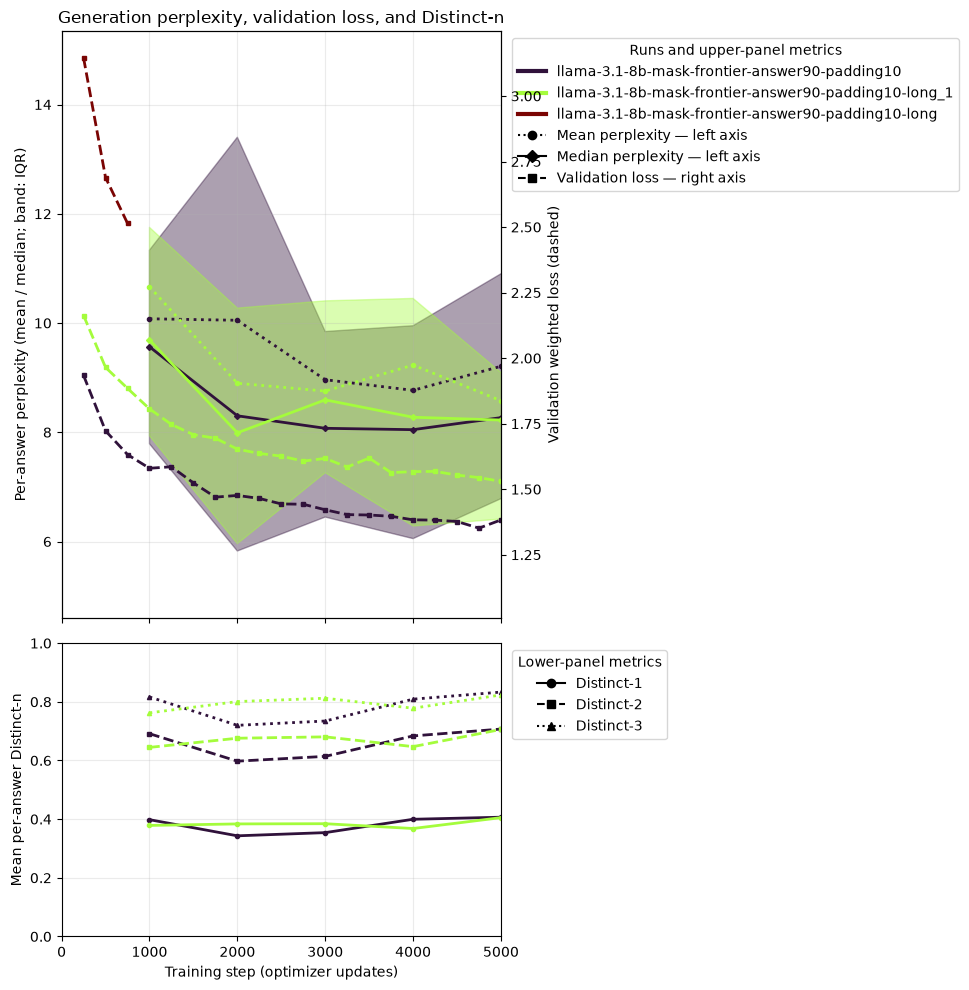

In [4]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, (ax, distinct_ax) = plt.subplots(
    2, 1, figsize=(12, 10), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)
loss_ax = ax.twinx()
plotted_runs = [name for name in dict.fromkeys(RUN_NAMES)
                if name in perplexity_summaries or name in distinct_summaries
                or name in validation_losses]
colors = plt.get_cmap("turbo" if len(plotted_runs) <= 20 else "turbo")
legend_handles = []
for index, run_name in enumerate(plotted_runs):
    color = colors(index / max(len(plotted_runs) - 1, 1))
    legend_handles.append(Line2D([], [], color=color, linewidth=3, label=run_name))
    summary = perplexity_summaries.get(run_name)
    if summary is not None:
        steps = summary.index.to_numpy(dtype=float)
        ax.plot(steps, summary["mean"].to_numpy(), color=color,
                linewidth=2, linestyle=":", marker="o", markersize=3)
        ax.plot(steps, summary["median"].to_numpy(), color=color,
                linewidth=2, linestyle="-", marker="D", markersize=3)
        ax.fill_between(steps, summary["q25"].to_numpy(), summary["q75"].to_numpy(),
                        color=color, alpha=0.4)
    loss = validation_losses.get(run_name)
    if loss is not None:
        loss_ax.plot(loss.index.to_numpy(dtype=float), loss.to_numpy(), color=color,
                     linewidth=2, linestyle="--", marker="s", markersize=3)
    distinct = distinct_summaries.get(run_name)
    if distinct is not None:
        distinct_steps = distinct.index.to_numpy(dtype=float)
        distinct_styles = {
            "distinct_1": ("-", "o"),
            "distinct_2": ("--", "s"),
            "distinct_3": (":", "^"),
        }
        for column, (linestyle, marker) in distinct_styles.items():
            if column in distinct:
                distinct_ax.plot(
                    distinct_steps, distinct[column].to_numpy(), color=color,
                    linewidth=2, linestyle=linestyle, marker=marker, markersize=3,
                )

LOG_VALIDATION_LOSS = False  # Set True if early, very large perplexities obscure later steps.

if LOG_Y:
    ax.set_yscale("log")
if LOG_VALIDATION_LOSS:
    loss_ax.set_yscale("log", nonpositive="mask")  # Zero loss has no finite log value.
ax.set(title="Generation perplexity, validation loss, and Distinct-n",
       ylabel="Per-answer perplexity (mean / median; band: IQR)")
loss_ax.set_ylabel("Validation weighted loss (dashed)")
ax.grid(True, alpha=0.25)
distinct_ax.set(
    xlabel="Training step (optimizer updates)",
    ylabel="Mean per-answer Distinct-n",
)
distinct_ax.set_ylim(0, 1)
distinct_ax.grid(True, alpha=0.25)
legend_handles.extend([
    Line2D([], [], color="black", linestyle=":", marker="o", label="Mean perplexity — left axis"),
    Line2D([], [], color="black", linestyle="-", marker="D", label="Median perplexity — left axis"),
    Line2D([], [], color="black", linestyle="--", marker="s", label="Validation loss — right axis"),
])
ax.legend(handles=legend_handles, title="Runs and upper-panel metrics",
          bbox_to_anchor=(1.01, 1), loc="upper left")
distinct_ax.legend(handles=[
    Line2D([], [], color="black", linestyle="-", marker="o", label="Distinct-1"),
    Line2D([], [], color="black", linestyle="--", marker="s", label="Distinct-2"),
    Line2D([], [], color="black", linestyle=":", marker="^", label="Distinct-3"),
], title="Lower-panel metrics", bbox_to_anchor=(1.01, 1), loc="upper left")

distinct_ax.set_xlim(0, 5_000)
fig.tight_layout(rect=(0, 0, 0.82, 1))
plt.show()

# Optional: save the displayed figure to Drive.
# fig.savefig(BASE_DIR.parent / "generation-quality-comparison.png", dpi=200, bbox_inches="tight")
